# Historgam Equalization to Foreground

In [118]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('jeniffer.jpg')

# Conver to HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)


H, S, V = cv2.split(hsv_image)


(a) Display HSV planes in Grayscale

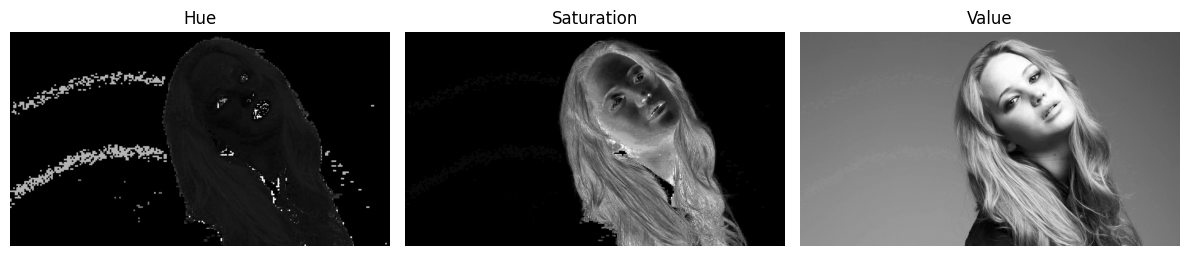

In [119]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap='gray')
plt.title('Hue')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(S, cmap='gray')
plt.title('Saturation')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray')
plt.title('Value')
plt.axis('off')

plt.tight_layout()

plt.show()

(b) Exract the foreground mask

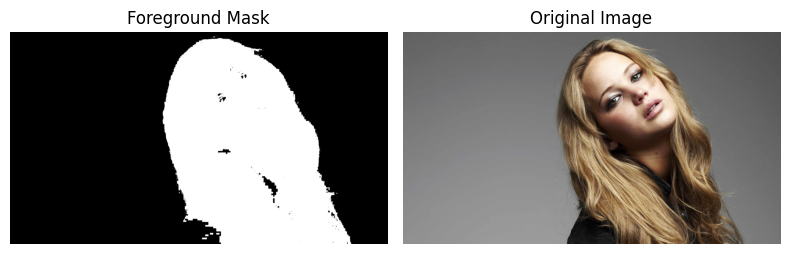

In [120]:
# Extract the foreground mask using a threshold on the Value channel
threshold = 13
ret , mask = cv2.threshold(S, threshold, 255, cv2.THRESH_BINARY) # background is gray while foreground is vivid

# Display the foreground mask and the original image
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()

plt.show()

(c) Foreground using cv2.bitwise_and and computing histogram

In [121]:
# get foreground
foreground = cv2.bitwise_and(S, S, mask=mask)

# compute histogram
#hist = cv2.calcHist([foreground], [0], mask, [256], [0,256])
#hist = hist.flatten()

hist = np.zeros(256, dtype=int)
for pixel in foreground.flatten():
    hist[pixel] += 1
    

Text(0, 0.5, 'Frequency')

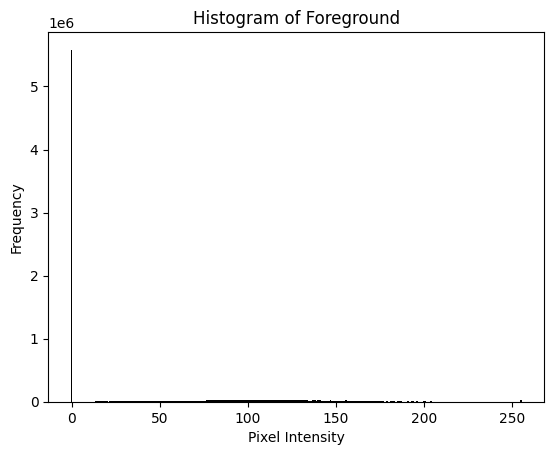

In [122]:



plt.bar(range(256), hist, width=1.0, color='black')
plt.title("Histogram of Foreground")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

(d)cdf

Text(0, 0.5, 'Frequency')

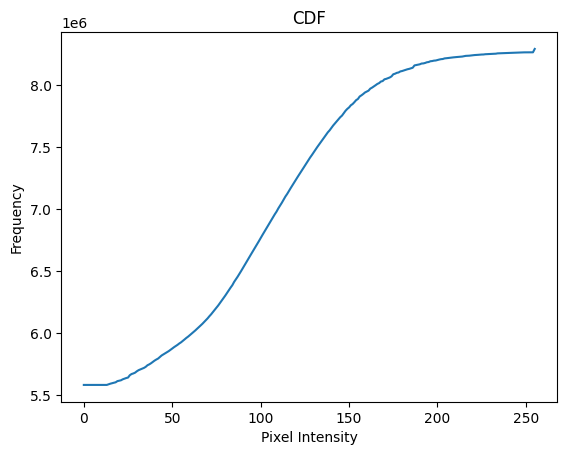

In [123]:
# Cumulative sum
cdf = np.cumsum(hist)

plt.title("CDF")
plt.plot(cdf)
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')



(e) histogram-equalize the foreground

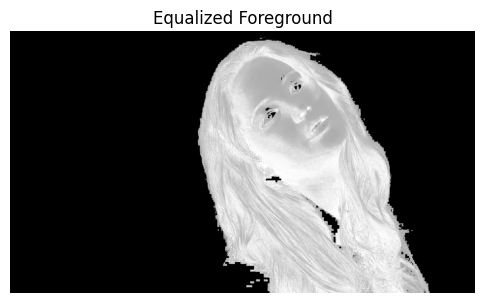

In [124]:
L = 256  #gray levels


foreground_pixels = np.sum(hist)  


# s = T(r) = ((L-1)/MN) * cdf[k]
equalization_map = np.floor(((L - 1) / foreground_pixels) * cdf).astype(np.uint8)

# Create an empty image for the equalized foreground
equalized_foreground = np.zeros_like(foreground)

# Apply the equalization map to foreground pixels only
foreground_indices = np.where(mask != 0)
for i, j in zip(*foreground_indices):
    pixel_val = foreground[i, j]
    equalized_foreground[i, j] = equalization_map[pixel_val]

# Display the equalized foreground
plt.figure(figsize=(6, 6))
plt.imshow(equalized_foreground, cmap='gray')
plt.title("Equalized Foreground")
plt.axis('off')

plt.show()


(f) Extract the background and add with the histogram equalized foreground

In [128]:
background = cv2.bitwise_and(S, S, mask=cv2.bitwise_not(mask))
S_eq = cv2.add(background, equalized_foreground)

# Recombine H, S, and new V plane
hsv_eq = cv2.merge([H, S_eq, V ])
bgr_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)



H,S,V planes

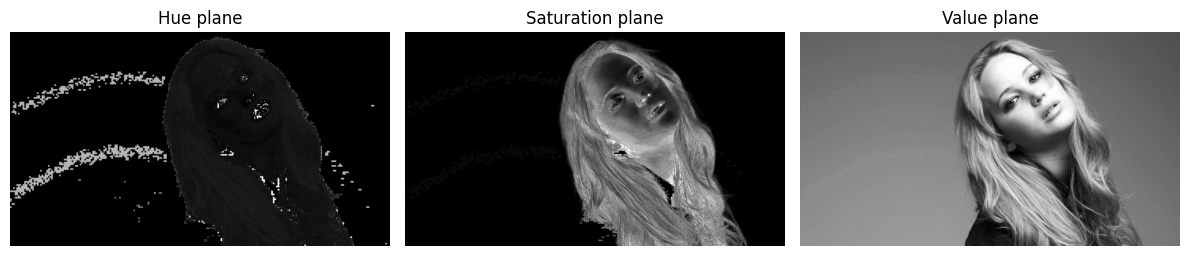

In [129]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(H, cmap='gray')
plt.title("Hue plane")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(S, cmap='gray')
plt.title("Saturation plane")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray')
plt.title("Value plane")
plt.axis('off')

plt.tight_layout()

plt.show()

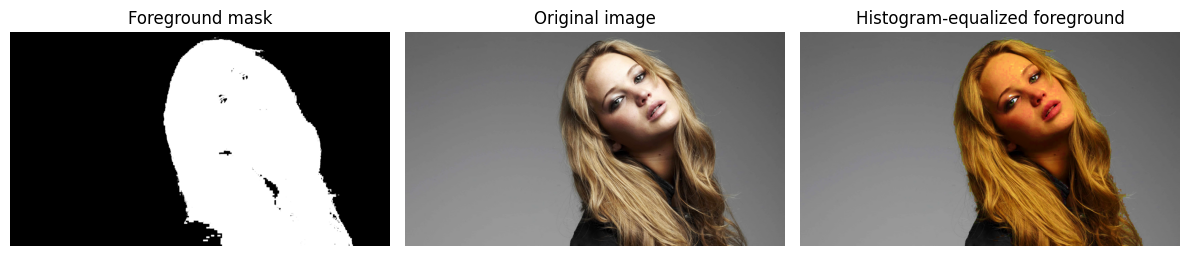

In [130]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.title("Foreground mask")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(bgr_eq, cv2.COLOR_BGR2RGB))
plt.title("Histogram-equalized foreground")
plt.axis('off')

plt.tight_layout()
plt.show()